In [1]:
%matplotlib widget

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox
import matplotlib.ticker as ticker


def lotka_volterra(t, z, a, b, c, d):
    x, y = z
    dxdt = a * x - b * x * y
    dydt = d * x * y - c * y
    return [dxdt, dydt]


def solve_and_plot(a, b, c, d, x0=10, y0=5):
    # Define time interval
    t_span = (0, 200)
    t_eval = np.linspace(t_span[0], t_span[1], 1000)

    # Solve the differential equations
    sol = solve_ivp(lotka_volterra, t_span, [x0, y0], args=(a, b, c, d), t_eval=t_eval)

    # Extract solutions
    t = sol.t
    x = sol.y[0]
    y = sol.y[1]

    # Define axis limits dynamically with a margin
    x_min, x_max = min(x) * 0.9, max(x) * 1.1
    y_min, y_max = min(y) * 0.9, max(y) * 1.1

    # Create figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Population dynamics plot
    axes[0].plot(t, x, label="Prey (x)", color="blue", linewidth=2)
    axes[0].plot(t, y, label="Predators (y)", color="red", linewidth=2)
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Population")
    axes[0].set_title("Predator-Prey Population Dynamics")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", linewidth=0.5)
    axes[0].set_xlim(0, 50)  # Keep time axis constant
    axes[0].set_ylim(0, max(max(x), max(y)) * 1.1)  # Adjust y-axis dynamically
    axes[0].xaxis.set_major_locator(ticker.MultipleLocator(20))
    axes[0].yaxis.set_major_locator(ticker.MultipleLocator(int(max(max(x), max(y)) // 5) or 1))

    # Phase space diagram
    axes[1].plot(x, y, color="purple", linewidth=2)
    axes[1].set_xlabel("Prey (x)")
    axes[1].set_ylabel("Predators (y)")
    axes[1].set_title("Phase Space Diagram")
    axes[1].grid(True, linestyle="--", linewidth=0.5)
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)
    axes[1].xaxis.set_major_locator(ticker.MultipleLocator(int((x_max - x_min) // 5) or 1))
    axes[1].yaxis.set_major_locator(ticker.MultipleLocator(int((y_max - y_min) // 5) or 1))

    # Parameter legend inside the second plot
    param_text = (
        f"Parameters:\n"
        f"Prey growth:   {a:.2f}\n"
        f"Predation:       {b:.2f}\n"
        f"Mortality:        {c:.2f}\n"
        f"Growth:        {d:.3f}\n"
        f"Initial values:\n"
        f"Prey:                  {x0}\n"
        f"Predator:            {y0}"
    )
  
    axes[1].text(1.02, 0.5, param_text, transform=axes[1].transAxes, fontsize=10,
                 verticalalignment='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

    plt.tight_layout()
    plt.show()


# Create sliders for parameters
slider_a = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='Prey growth rate (a)')
slider_b = widgets.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01, description='Predation rate (b)')
slider_c = widgets.FloatSlider(value=1.5, min=0.1, max=3.0, step=0.1, description='Predator mortality rate (c)')
slider_d = widgets.FloatSlider(value=0.075, min=0.01, max=0.2, step=0.005, description='Predator growth rate (d)')
slider_x0 = widgets.IntSlider(value=10, min=1, max=1000, step=1, description='Initial prey population (x0)')
slider_y0 = widgets.IntSlider(value=5, min=1, max=1000, step=1, description='Initial predator population (y0)')

# Organize sliders into two columns (3 sliders per column)
ui = HBox([
    VBox([slider_a, slider_b, slider_c]),  
    VBox([slider_d, slider_x0, slider_y0])  
])

# Link the sliders to the function
out = widgets.interactive_output(solve_and_plot, {'a': slider_a, 'b': slider_b, 'c': slider_c, 
                                                  'd': slider_d, 'x0': slider_x0, 'y0': slider_y0})

# Display UI
display(ui, out)


Output()

# Model MAY

In [2]:
# Re-import necessary libraries after execution state reset
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

# Define the May Model equations in discrete form
def may_model(H_t, P_t, F, a, k):
    H_t1 = F * H_t * (1 + a * P_t / k) ** -k
    P_t1 = H_t - H_t1 / F
    return H_t1, P_t1

# Function to simulate and plot the May Model

# Corrected function to simulate and plot the May Model
def solve_and_plot_may(F, a, k, H0=10, P0=5, generations=80):
    # Initialize arrays
    H = [H0]
    P = [P0]

    # Iterate over generations
    for t in range(generations):
        H_t1, P_t1 = may_model(H[-1], P[-1], F, a, k)
        H.append(H_t1)
        P.append(P_t1)

    # Define axis limits dynamically
    H_min, H_max = min(H) * 0.9, max(H) * 1.1
    P_min, P_max = min(P) * 0.9, max(P) * 1.1

    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Population dynamics plot
    axes[0].plot(range(generations + 1), H, label="Hosts (H)", color="blue", linewidth=2)
    axes[0].plot(range(generations + 1), P, label="Parasitoids (P)", color="red", linewidth=2)
    axes[0].set_xlabel("Generations")
    axes[0].set_ylabel("Population")
    axes[0].set_title(f'Host-Parasitoid Population Dynamics with k = {k:.2f}')
    axes[0].legend()
    axes[0].grid(True, linestyle="--", linewidth=0.5)
    axes[0].set_ylim(0, max(max(H), max(P)) * 1.1)

    # Phase space diagram
    axes[1].plot(H, P, color="purple", linewidth=2)
    axes[1].set_xlabel("Hosts (H)")
    axes[1].set_ylabel("Parasitoids (P)")
    axes[1].set_title(f'Phase Space Diagram with k = {k:.2f}')
    axes[1].grid(True, linestyle="--", linewidth=0.5)
    axes[1].set_xlim(H_min, H_max)
    axes[1].set_ylim(P_min, P_max)

    # Parameter legend inside the second plot
    param_text = (
        f"Parameters:\n"
        f"Host reproduction (F): {F:.2f}\n"
        f"Search efficiency (a): {a:.2f}\n"
        f"Clustering (k): {k:.2f}\n"
        f"Initial values:\n"
        f"Hosts (H0): {H0}\n"
        f"Parasitoids (P0): {P0}"
    )
  
    axes[1].text(1.02, 0.5, param_text, transform=axes[1].transAxes, fontsize=10,
                 verticalalignment='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

    plt.tight_layout()
    plt.show()

# Create sliders for parameters
slider_F = widgets.FloatSlider(value=2.0, min=1.0, max=3.0, step=0.1, description='Host Reproduction (F)')
slider_a = widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.1, description='Search Efficiency (a)')
slider_k = widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='Clustering Parameter (k)')
slider_H0 = widgets.IntSlider(value=10, min=1, max=100, step=1, description='Initial Hosts (H0)')
slider_P0 = widgets.IntSlider(value=5, min=1, max=100, step=1, description='Initial Parasitoids (P0)')

# Organize sliders into two columns
ui_may = HBox([
    VBox([slider_F, slider_a, slider_k]),  
    VBox([slider_H0, slider_P0])  
])

# Link the sliders to the function
out_may = widgets.interactive_output(solve_and_plot_may, {'F': slider_F, 'a': slider_a, 'k': slider_k, 
                                                          'H0': slider_H0, 'P0': slider_P0})

# Display UI
display(ui_may, out_may)


Output()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

# Define the May Model equations in discrete form
def may_model(H_t, P_t, F, a, k):
    H_t1 = F * H_t * (1 + a * P_t / k) ** -k
    P_t1 = H_t - H_t1 / F
    return H_t1, P_t1

# Function to simulate and plot the May Model with stability check
def solve_and_plot_may(F, a, k, H0=10, P0=5, generations=80):
    # Initialize arrays
    H = [H0]
    P = [P0]

    # Iterate over generations
    for t in range(generations):
        H_t1, P_t1 = may_model(H[-1], P[-1], F, a, k)
        H.append(H_t1)
        P.append(P_t1)
    
    # Stability condition check
    stable = k < 1
    
    # Define axis limits dynamically
    H_min, H_max = min(H) * 0.9, max(H) * 1.1
    P_min, P_max = min(P) * 0.9, max(P) * 1.1

    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Population dynamics plot
    axes[0].plot(range(generations + 1), H, label="Hosts (H)", color="blue", linewidth=2)
    axes[0].plot(range(generations + 1), P, label="Parasitoids (P)", color="red", linewidth=2)
    axes[0].set_xlabel("Generations")
    axes[0].set_ylabel("Population")
    axes[0].set_title(f'Host-Parasitoid Population Dynamics with k = {k:.2f}')
    axes[0].legend()
    axes[0].grid(True, linestyle="--", linewidth=0.5)
    axes[0].set_ylim(0, max(max(H), max(P)) * 1.1)
    
    # Stability annotation
    if not stable:
        axes[0].text(0.5, 0.9, "Unstable system!", transform=axes[0].transAxes, fontsize=14, color='red',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

    # Phase space diagram
    axes[1].plot(H, P, color="purple", linewidth=2)
    axes[1].set_xlabel("Hosts (H)")
    axes[1].set_ylabel("Parasitoids (P)")
    axes[1].set_title(f'Phase Space Diagram with k = {k:.2f}')
    axes[1].grid(True, linestyle="--", linewidth=0.5)
    axes[1].set_xlim(H_min, H_max)
    axes[1].set_ylim(P_min, P_max)

    # Parameter legend inside the second plot
    param_text = (
        f"Parameters:\n"
        f"Host reproduction (F): {F:.2f}\n"
        f"Search efficiency (a): {a:.2f}\n"
        f"Clustering (k): {k:.2f}\n"
        f"Initial values:\n"
        f"Hosts (H0): {H0}\n"
        f"Parasitoids (P0): {P0}"
    )

    axes[1].text(1.02, 0.5, param_text, transform=axes[1].transAxes, fontsize=10,
                 verticalalignment='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

    plt.tight_layout()
    plt.show()

# Create sliders for parameters
slider_F = widgets.FloatSlider(value=2.0, min=1.0, max=3.0, step=0.1, description='Host Reproduction (F)')
slider_a = widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.1, description='Search Efficiency (a)')
slider_k = widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='Clustering Parameter (k)')
slider_H0 = widgets.IntSlider(value=10, min=1, max=100, step=1, description='Initial Hosts (H0)')
slider_P0 = widgets.IntSlider(value=5, min=1, max=100, step=1, description='Initial Parasitoids (P0)')

# Organize sliders into two columns
ui_may = HBox([
    VBox([slider_F, slider_a, slider_k]),  
    VBox([slider_H0, slider_P0])  
])

# Link the sliders to the function
out_may = widgets.interactive_output(solve_and_plot_may, {'F': slider_F, 'a': slider_a, 'k': slider_k, 
                                                          'H0': slider_H0, 'P0': slider_P0})

# Display UI
display(ui_may, out_may)

Output()

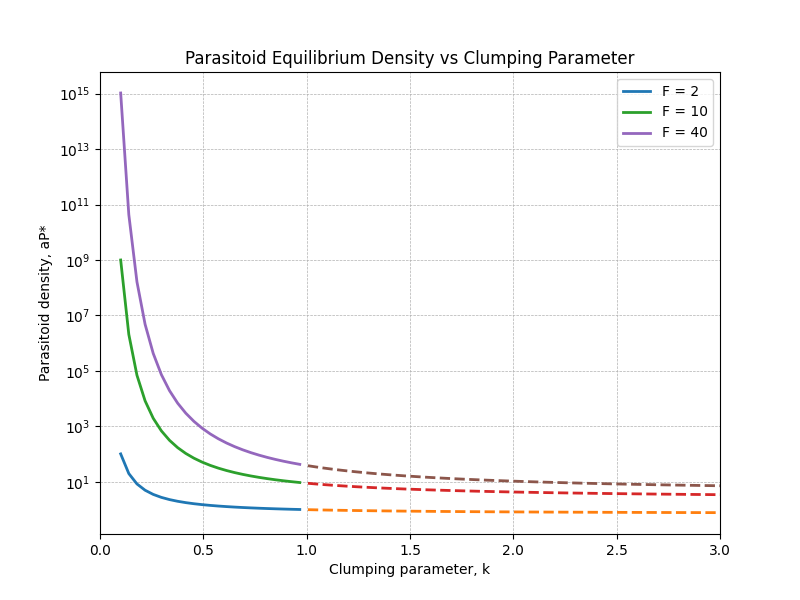

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros según la teoría de May
F_values = [ 2, 10,40]  # Diferentes valores de fecundidad del hospedador
k_values = np.linspace(0.1, 4, 100)  # Rango del parámetro de agrupamiento k
a = 3  # Escalamiento arbitrario de la tasa de búsqueda

# Función para calcular la densidad de parasitoides en equilibrio
def parasitoid_density(F, k):
    return k * (F**(1/k) - 1)

# Crear la figura
plt.figure(figsize=(8, 6))

# Graficar para cada valor de F
for F in F_values:
    aP_star = parasitoid_density(F, k_values)
    stable_k = k_values < 1  # Según la teoría, k < 1 es estable
    unstable_k = ~stable_k  # k >= 1 es inestable

    # Parte estable (línea sólida)
    plt.plot(k_values[stable_k], aP_star[stable_k], label=f"F = {F}", linewidth=2)

    # Parte inestable (línea discontinua)
    plt.plot(k_values[unstable_k], aP_star[unstable_k], linestyle='dashed', linewidth=2)

# Configuración del gráfico
plt.xlim(0, 3)
plt.yscale("log")  # Escala logarítmica para la densidad de parasitoides
plt.xlabel("Clumping parameter, k")
plt.ylabel("Parasitoid density, aP*")
plt.title("Parasitoid Equilibrium Density vs Clumping Parameter")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Mostrar la figura
plt.show()
